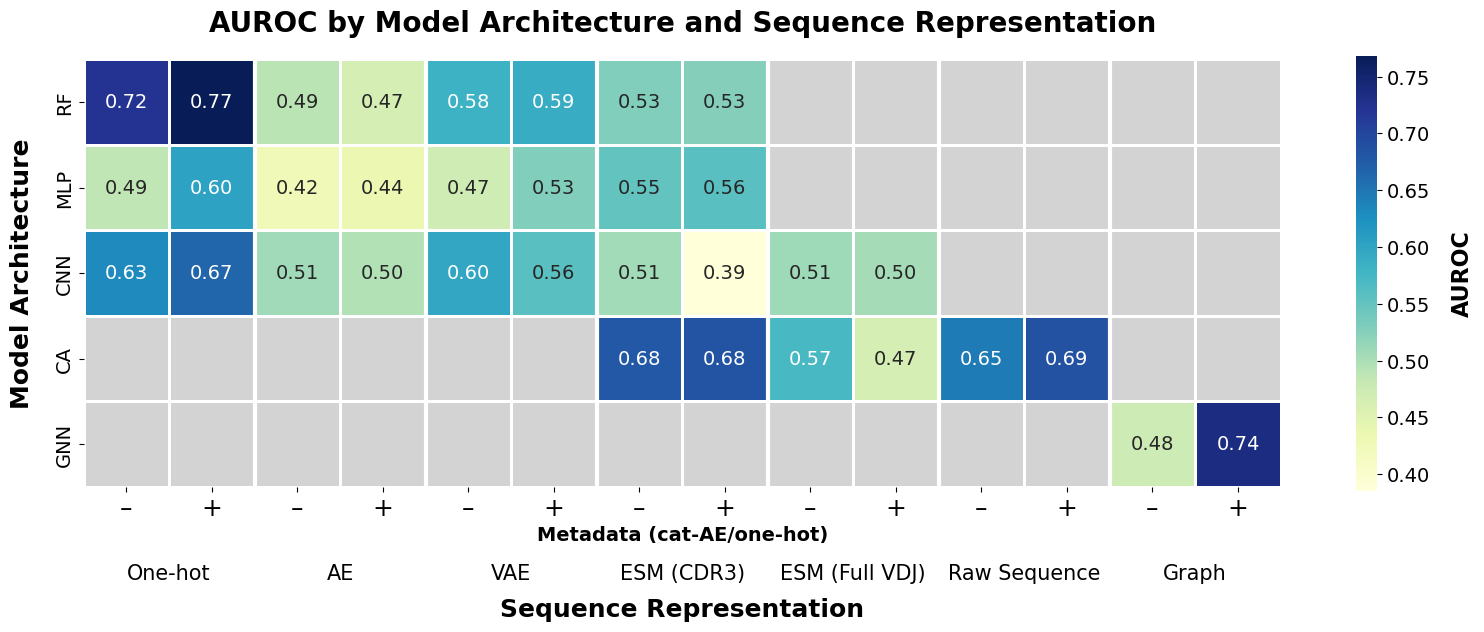

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv(r'outputs\models\all_results_summary.csv')

# 2. Clean and Extract Labels
def get_representation(name):
    name = name.lower()
    if 'esm_cdr3' in name or 'esm-cdr3' in name: return 'ESM (CDR3)'
    if 'esm_full' in name or 'esm-full' in name: return 'ESM (Full VDJ)'
    if 'vae' in name: return 'VAE'
    if 'one_hot' in name or 'onehot' in name: return 'One-hot'
    if 'raw' in name: return 'Raw Sequence'
    if 'gnn' in name: return 'Graph'
    if 'autoencoder' in name or 'ae' in name.split('_'): return 'AE'
    return 'Unknown'

def get_metadata_flag(row):
    vals = [str(row.get('metadata')), str(row.get('feature_augment')), str(row.get('categorical'))]
    for v in vals:
        if 'cat_ae' in v or 'one_hot' in v:
            return '+'
    if 'meta' in str(row['experiment_name']):
        return '+'
    return '–'

df['Representation'] = df['experiment_name'].apply(get_representation)
df['Metadata'] = df.apply(get_metadata_flag, axis=1)
df['Model'] = df['model'].replace({'cnn': 'CNN', 'cross_attention': 'CA', 'gnn': 'GNN', 'mlp': 'MLP', 'random_forest': 'RF'})

# 3. Define the Grid Ordering
rep_order = ['One-hot', 'AE', 'VAE', 'ESM (CDR3)', 'ESM (Full VDJ)', 'Raw Sequence', 'Graph']
model_order = ['RF', 'MLP', 'CNN', 'CA', 'GNN']

# 4. Create the Pivot Table
pivot_df = df.pivot_table(index='Model', columns=['Representation', 'Metadata'], values='auroc', aggfunc='max')

cols = pd.MultiIndex.from_product([rep_order, ['–', '+']], names=['Representation', 'Metadata'])
pivot_df = pivot_df.reindex(index=model_order, columns=cols)

# 5. Plotting
# Added an extra inch to the height to give the bottom margin more room
fig, ax = plt.subplots(figsize=(16, 9)) 

ax.set_facecolor('#d3d3d3')

sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", 
            linewidths=1, linecolor='white', 
            annot_kws={"size": 14}, cbar_kws={"shrink": 0.5},
            cbar=True, ax=ax,
            mask=pivot_df.isna(), square=True)

# 6. Format Colorbar 
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('AUROC', size=16, weight='bold', labelpad=15)

# 7. Format Y-Axis 
ax.set_ylabel('Model Architecture', fontsize=18, fontweight='bold', labelpad=15)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight='normal')

# 8. Format X-Axis 
x_labels = [metadata for rep, metadata in pivot_df.columns]
ax.set_xticks(np.arange(len(x_labels)) + 0.5)
ax.set_xticklabels(x_labels, fontsize=18, fontweight='normal', rotation=0)

# Clear the default xlabel so it doesn't fight the manual text placements
ax.set_xlabel('')

# LEVEL 1: The Metadata Subtitle
# Adjust the '+ 0.3' to shift this string closer to or further from the +/- ticks
ax.text(len(pivot_df.columns) / 2, len(model_order) + 0.45, 
        'Metadata (cat-AE/one-hot)', 
        ha='center', va='top', fontsize=14, fontweight='bold')

# LEVEL 2: The Individual Representation Labels
for i, rep in enumerate(rep_order):
    x_center = (i * 2) + 1 
    # Adjust the '+ 0.7' to shift the representation names (One-hot, AE, etc.)
    y_pos = len(model_order) + 0.9
    ax.text(x_center, y_pos, rep, ha='center', va='top', fontsize=15, fontweight='normal')

# LEVEL 3: The Main Sequence Representation Title
# Adjust the '+ 1.1' to shift the overarching bottom title up or down
ax.text(len(pivot_df.columns) / 2, len(model_order) + 1.3, 
        'Sequence Representation', 
        ha='center', va='top', fontsize=18, fontweight='bold')

# Draw vertical divider lines
for i in range(1, len(rep_order)):
    ax.axvline(x=i*2, color='white', linewidth=3)

# 9. Format Main Title
plt.title('AUROC by Model Architecture and Sequence Representation', fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

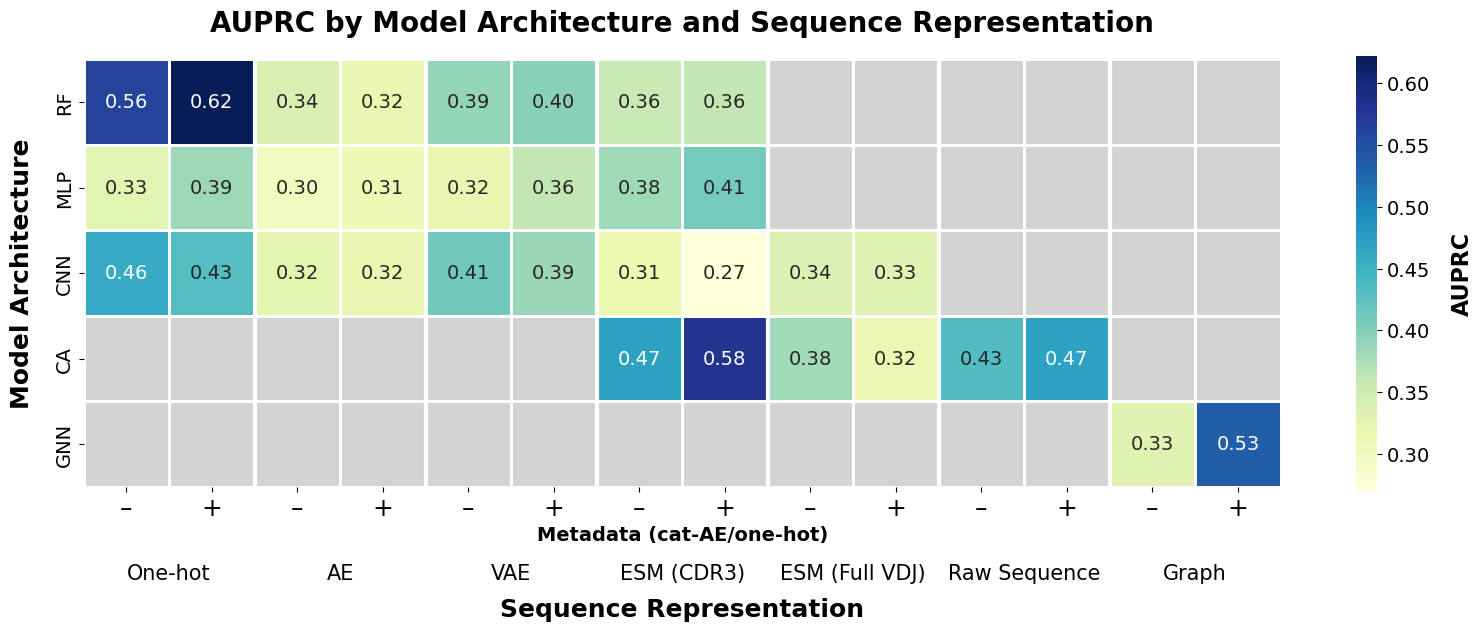

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv(r'outputs\models\all_results_summary.csv')

# 2. Clean and Extract Labels
def get_representation(name):
    name = name.lower()
    if 'esm_cdr3' in name or 'esm-cdr3' in name: return 'ESM (CDR3)'
    if 'esm_full' in name or 'esm-full' in name: return 'ESM (Full VDJ)'
    if 'vae' in name: return 'VAE'
    if 'one_hot' in name or 'onehot' in name: return 'One-hot'
    if 'raw' in name: return 'Raw Sequence'
    if 'gnn' in name: return 'Graph'
    if 'autoencoder' in name or 'ae' in name.split('_'): return 'AE'
    return 'Unknown'

def get_metadata_flag(row):
    vals = [str(row.get('metadata')), str(row.get('feature_augment')), str(row.get('categorical'))]
    for v in vals:
        if 'cat_ae' in v or 'one_hot' in v:
            return '+'
    if 'meta' in str(row['experiment_name']):
        return '+'
    return '–'

df['Representation'] = df['experiment_name'].apply(get_representation)
df['Metadata'] = df.apply(get_metadata_flag, axis=1)
df['Model'] = df['model'].replace({'cnn': 'CNN', 'cross_attention': 'CA', 'gnn': 'GNN', 'mlp': 'MLP', 'random_forest': 'RF'})

# 3. Define the Grid Ordering
rep_order = ['One-hot', 'AE', 'VAE', 'ESM (CDR3)', 'ESM (Full VDJ)', 'Raw Sequence', 'Graph']
model_order = ['RF', 'MLP', 'CNN', 'CA', 'GNN']

# 4. Create the Pivot Table
pivot_df = df.pivot_table(index='Model', columns=['Representation', 'Metadata'], values='auprc', aggfunc='max')

cols = pd.MultiIndex.from_product([rep_order, ['–', '+']], names=['Representation', 'Metadata'])
pivot_df = pivot_df.reindex(index=model_order, columns=cols)

# 5. Plotting
# Added an extra inch to the height to give the bottom margin more room
fig, ax = plt.subplots(figsize=(16, 9)) 

ax.set_facecolor('#d3d3d3')

sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", 
            linewidths=1, linecolor='white', 
            annot_kws={"size": 14}, cbar_kws={"shrink": 0.5},
            cbar=True, ax=ax,
            mask=pivot_df.isna(), square=True)

# 6. Format Colorbar 
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('AUPRC', size=16, weight='bold', labelpad=15)

# 7. Format Y-Axis 
ax.set_ylabel('Model Architecture', fontsize=18, fontweight='bold', labelpad=15)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight='normal')

# 8. Format X-Axis 
x_labels = [metadata for rep, metadata in pivot_df.columns]
ax.set_xticks(np.arange(len(x_labels)) + 0.5)
ax.set_xticklabels(x_labels, fontsize=18, fontweight='normal', rotation=0)

# Clear the default xlabel so it doesn't fight the manual text placements
ax.set_xlabel('')

# LEVEL 1: The Metadata Subtitle
# Adjust the '+ 0.3' to shift this string closer to or further from the +/- ticks
ax.text(len(pivot_df.columns) / 2, len(model_order) + 0.45, 
        'Metadata (cat-AE/one-hot)', 
        ha='center', va='top', fontsize=14, fontweight='bold')

# LEVEL 2: The Individual Representation Labels
for i, rep in enumerate(rep_order):
    x_center = (i * 2) + 1 
    # Adjust the '+ 0.7' to shift the representation names (One-hot, AE, etc.)
    y_pos = len(model_order) + 0.9
    ax.text(x_center, y_pos, rep, ha='center', va='top', fontsize=15, fontweight='normal')

# LEVEL 3: The Main Sequence Representation Title
# Adjust the '+ 1.1' to shift the overarching bottom title up or down
ax.text(len(pivot_df.columns) / 2, len(model_order) + 1.3, 
        'Sequence Representation', 
        ha='center', va='top', fontsize=18, fontweight='bold')

# Draw vertical divider lines
for i in range(1, len(rep_order)):
    ax.axvline(x=i*2, color='white', linewidth=3)

# 9. Format Main Title
plt.title('AUPRC by Model Architecture and Sequence Representation', fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

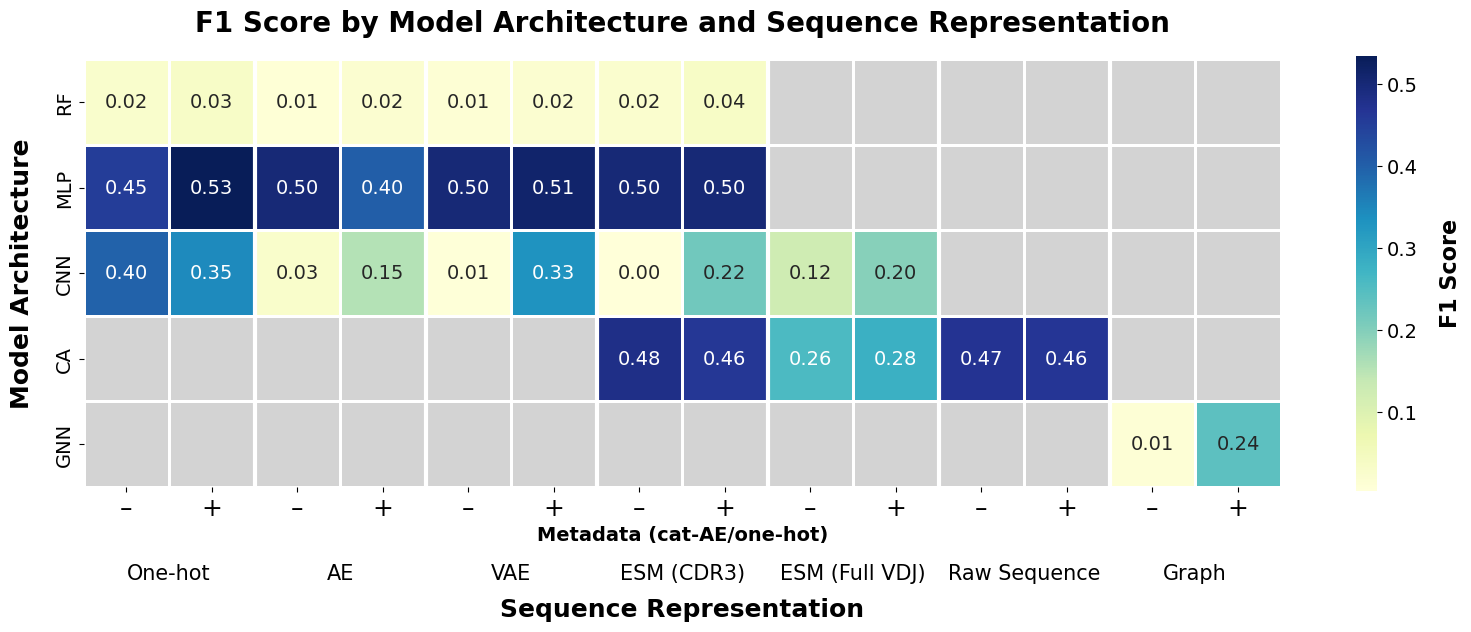

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv(r'outputs\models\all_results_summary.csv')

# 2. Clean and Extract Labels
def get_representation(name):
    name = name.lower()
    if 'esm_cdr3' in name or 'esm-cdr3' in name: return 'ESM (CDR3)'
    if 'esm_full' in name or 'esm-full' in name: return 'ESM (Full VDJ)'
    if 'vae' in name: return 'VAE'
    if 'one_hot' in name or 'onehot' in name: return 'One-hot'
    if 'raw' in name: return 'Raw Sequence'
    if 'gnn' in name: return 'Graph'
    if 'autoencoder' in name or 'ae' in name.split('_'): return 'AE'
    return 'Unknown'

def get_metadata_flag(row):
    vals = [str(row.get('metadata')), str(row.get('feature_augment')), str(row.get('categorical'))]
    for v in vals:
        if 'cat_ae' in v or 'one_hot' in v:
            return '+'
    if 'meta' in str(row['experiment_name']):
        return '+'
    return '–'

df['Representation'] = df['experiment_name'].apply(get_representation)
df['Metadata'] = df.apply(get_metadata_flag, axis=1)
df['Model'] = df['model'].replace({'cnn': 'CNN', 'cross_attention': 'CA', 'gnn': 'GNN', 'mlp': 'MLP', 'random_forest': 'RF'})

# 3. Define the Grid Ordering
rep_order = ['One-hot', 'AE', 'VAE', 'ESM (CDR3)', 'ESM (Full VDJ)', 'Raw Sequence', 'Graph']
model_order = ['RF', 'MLP', 'CNN', 'CA', 'GNN']

# 4. Create the Pivot Table
pivot_df = df.pivot_table(index='Model', columns=['Representation', 'Metadata'], values='f1', aggfunc='max')

cols = pd.MultiIndex.from_product([rep_order, ['–', '+']], names=['Representation', 'Metadata'])
pivot_df = pivot_df.reindex(index=model_order, columns=cols)

# 5. Plotting
# Added an extra inch to the height to give the bottom margin more room
fig, ax = plt.subplots(figsize=(16, 9)) 

ax.set_facecolor('#d3d3d3')

sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", 
            linewidths=1, linecolor='white', 
            annot_kws={"size": 14}, cbar_kws={"shrink": 0.5},
            cbar=True, ax=ax,
            mask=pivot_df.isna(), square=True)

# 6. Format Colorbar 
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('F1 Score', size=16, weight='bold', labelpad=15)

# 7. Format Y-Axis 
ax.set_ylabel('Model Architecture', fontsize=18, fontweight='bold', labelpad=15)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight='normal')

# 8. Format X-Axis 
x_labels = [metadata for rep, metadata in pivot_df.columns]
ax.set_xticks(np.arange(len(x_labels)) + 0.5)
ax.set_xticklabels(x_labels, fontsize=18, fontweight='normal', rotation=0)

# Clear the default xlabel so it doesn't fight the manual text placements
ax.set_xlabel('')

# LEVEL 1: The Metadata Subtitle
# Adjust the '+ 0.3' to shift this string closer to or further from the +/- ticks
ax.text(len(pivot_df.columns) / 2, len(model_order) + 0.45, 
        'Metadata (cat-AE/one-hot)', 
        ha='center', va='top', fontsize=14, fontweight='bold')

# LEVEL 2: The Individual Representation Labels
for i, rep in enumerate(rep_order):
    x_center = (i * 2) + 1 
    # Adjust the '+ 0.7' to shift the representation names (One-hot, AE, etc.)
    y_pos = len(model_order) + 0.9
    ax.text(x_center, y_pos, rep, ha='center', va='top', fontsize=15, fontweight='normal')

# LEVEL 3: The Main Sequence Representation Title
# Adjust the '+ 1.1' to shift the overarching bottom title up or down
ax.text(len(pivot_df.columns) / 2, len(model_order) + 1.3, 
        'Sequence Representation', 
        ha='center', va='top', fontsize=18, fontweight='bold')

# Draw vertical divider lines
for i in range(1, len(rep_order)):
    ax.axvline(x=i*2, color='white', linewidth=3)

# 9. Format Main Title
plt.title('F1 Score by Model Architecture and Sequence Representation', fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

C:\Users\ChemEGrad2025\AppData\Local\Temp\ipykernel_41936\706919020.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(best_trials['Representation'], fontsize=14, rotation=15)


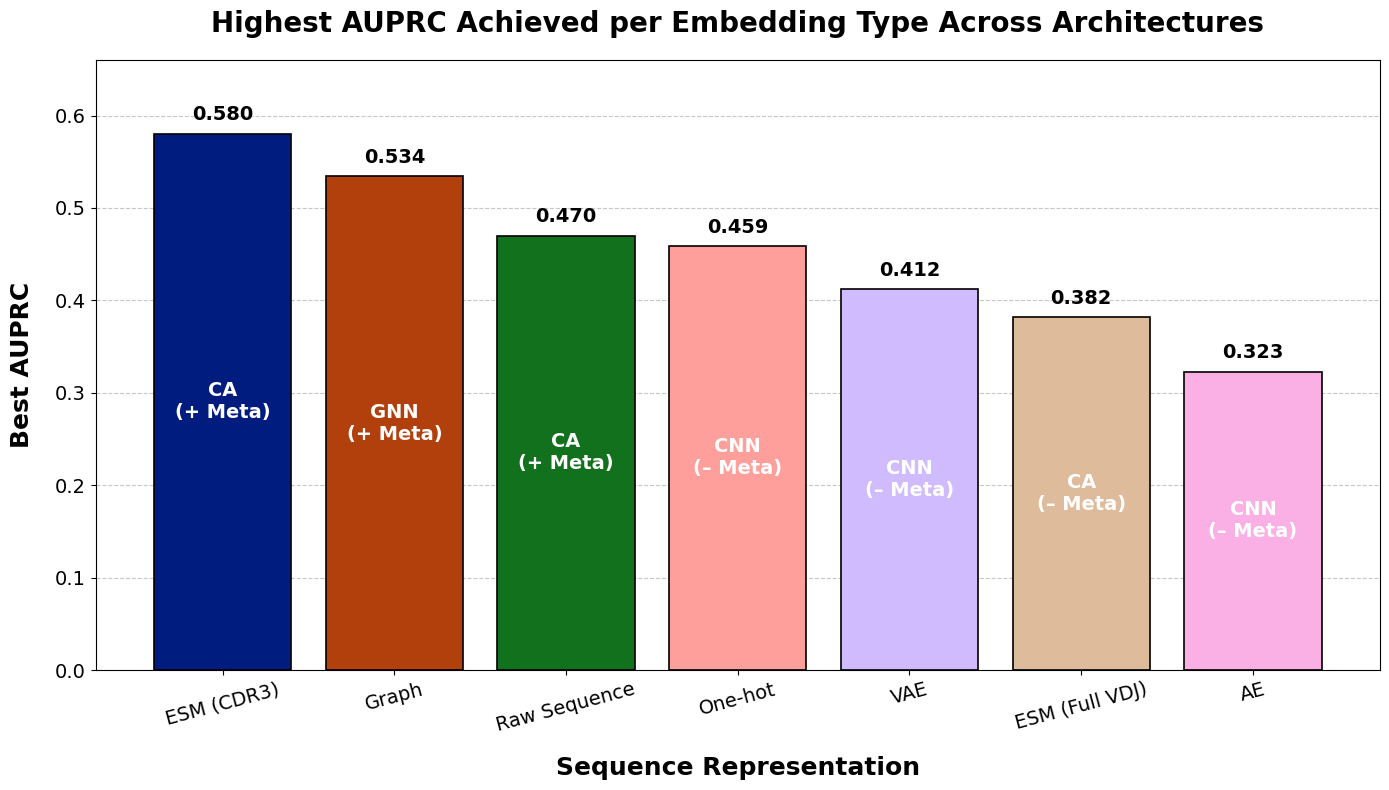

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch


# 2. Clean and Extract Labels
def get_representation(name):
    name = str(name).lower()
    if 'esm_cdr3' in name or 'esm-cdr3' in name: return 'ESM (CDR3)'
    if 'esm_full' in name or 'esm-full' in name: return 'ESM (Full VDJ)'
    if 'vae' in name: return 'VAE'
    if 'one_hot' in name or 'onehot' in name: return 'One-hot'
    if 'raw' in name: return 'Raw Sequence'
    if 'gnn' in name: return 'Graph'
    if 'autoencoder' in name or 'ae' in name.split('_'): return 'AE'
    return 'Unknown'

def get_metadata_flag(row):
    vals = [str(row.get('metadata')), str(row.get('feature_augment')), str(row.get('categorical'))]
    for v in vals:
        if 'cat_ae' in v or 'one_hot' in v:
            return '+ Meta'
    if 'meta' in str(row['experiment_name']):
        return '+ Meta'
    return '– Meta'

df['Representation'] = df['experiment_name'].apply(get_representation)
df['Metadata'] = df.apply(get_metadata_flag, axis=1)
df['Model'] = df['model'].replace({
    'cnn': 'CNN', 
    'cross_attention': 'CA', 
    'gnn': 'GNN', 
    'mlp': 'MLP', 
    'random_forest': 'RF'
})

# --- DROP-IN CODE TO EXCLUDE RF ---
df = df[df['Model'] != 'RF']
# ----------------------------------

# 3. Find the single best trial for each Representation based on AUPRC
best_idx = df.groupby('Representation')['auprc'].idxmax()
best_trials = df.loc[best_idx].copy()

# Filter out 'Unknown' and sort by AUPRC descending for a clean bar chart
best_trials = best_trials[best_trials['Representation'] != 'Unknown'].sort_values('auprc', ascending=False)

# 4. Plotting Setup
fig, ax = plt.subplots(figsize=(14, 8))

# ---------------------------------------------------------
# NEW LOGIC: Dynamic Color Mapping matching Panel 2
# ---------------------------------------------------------
# Generate both palettes so we can select the appropriate one
deep_colors = sns.color_palette("dark", len(best_trials))
muted_colors = sns.color_palette("pastel", len(best_trials)) # Matches Panel 2's minus-meta color

# Map the color for each bar individually based on its metadata flag
bar_colors = []
for i, metadata in enumerate(best_trials['Metadata']):
    if metadata == '+ Meta':
        bar_colors.append(deep_colors[i])
    else:
        bar_colors.append(muted_colors[i])

# Create bar plot with the dynamic color list
bars = ax.bar(best_trials['Representation'], best_trials['auprc'], 
              color=bar_colors, edgecolor='black', linewidth=1.2)
# ---------------------------------------------------------


# 5. Add labels indicating model architecture, metadata flag, and AUPRC
for bar, model, meta, val in zip(bars, best_trials['Model'], best_trials['Metadata'], best_trials['auprc']):
    height = bar.get_height()
    label_text = f"{model}\n({meta})"
    
    # Place Model and Metadata text inside the middle of the bar
    ax.text(bar.get_x() + bar.get_width() / 2., height / 2, label_text,
            ha='center', va='center', color='white', fontsize=14, fontweight='bold')
    
    # Place the AUPRC value slightly above the bar
    ax.text(bar.get_x() + bar.get_width() / 2., height + 0.01, f"{val:.3f}",
            ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')

# 6. Formatting
ax.set_ylabel('Best AUPRC', fontsize=18, fontweight='bold', labelpad=15)
ax.set_xlabel('Sequence Representation', fontsize=18, fontweight='bold', labelpad=15)
ax.set_title('Highest AUPRC Achieved per Embedding Type Across Architectures', fontsize=20, fontweight='bold', pad=20)
ax.set_xticklabels(best_trials['Representation'], fontsize=14, rotation=15)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(0, best_trials['auprc'].max() + 0.08) # Add some padding to the top for the labels

# Set subtle gridlines in the background for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

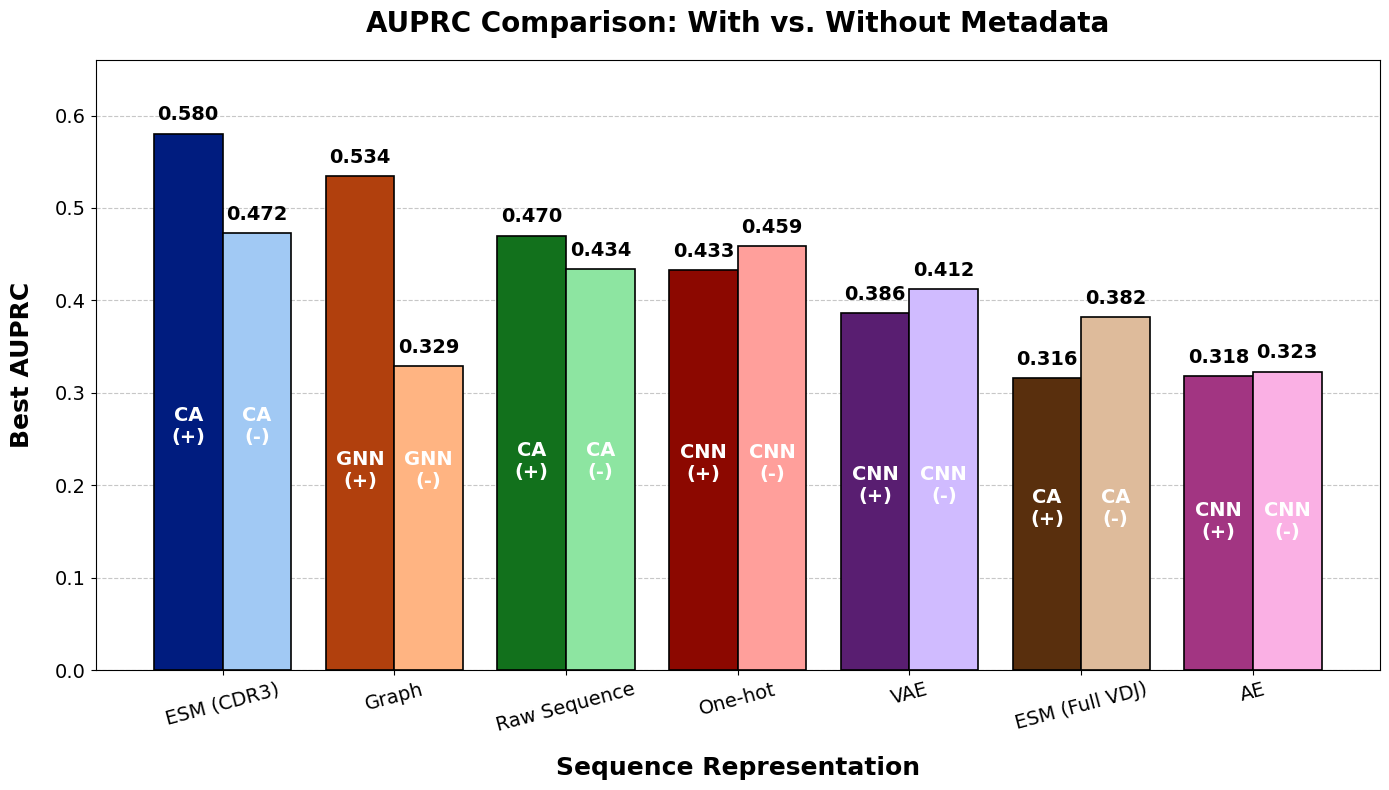

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Load Data

# 2. Clean and Extract Labels
def get_representation(name):
    name = str(name).lower()
    if 'esm_cdr3' in name or 'esm-cdr3' in name: return 'ESM (CDR3)'
    if 'esm_full' in name or 'esm-full' in name: return 'ESM (Full VDJ)'
    if 'vae' in name: return 'VAE'
    if 'one_hot' in name or 'onehot' in name: return 'One-hot'
    if 'raw' in name: return 'Raw Sequence'
    if 'gnn' in name: return 'Graph'
    if 'autoencoder' in name or 'ae' in name.split('_'): return 'AE'
    return 'Unknown'

def get_metadata_flag(row):
    vals = [str(row.get('metadata')), str(row.get('feature_augment')), str(row.get('categorical'))]
    for v in vals:
        if 'cat_ae' in v or 'one_hot' in v:
            return '+ Meta'
    if 'meta' in str(row['experiment_name']):
        return '+ Meta'
    return '– Meta'

df['Representation'] = df['experiment_name'].apply(get_representation)
df['Metadata'] = df.apply(get_metadata_flag, axis=1)
df['Model'] = df['model'].replace({
    'cnn': 'CNN', 
    'cross_attention': 'CA', 
    'gnn': 'GNN', 
    'mlp': 'MLP', 
    'random_forest': 'RF'
})

# --- DROP-IN CODE TO EXCLUDE RF ---
df = df[df['Model'] != 'RF']
# ----------------------------------

# 3. Get the original sorting order from the single best overall trials
best_overall_idx = df.groupby('Representation')['auprc'].idxmax()
best_overall_trials = df.loc[best_overall_idx].copy()
best_overall_trials = best_overall_trials[best_overall_trials['Representation'] != 'Unknown'].sort_values('auprc', ascending=False)
rep_order = best_overall_trials['Representation'].tolist()

# 4. Filter for Controlled Ablation (Matching the best model architecture per embedding)
plot_data = pd.DataFrame(index=rep_order)
plus_meta_vals, minus_meta_vals = [], []
plus_meta_models, minus_meta_models = [], []

for rep in rep_order:
    best_model_for_rep = best_overall_trials[best_overall_trials['Representation'] == rep]['Model'].values[0]
    subset = df[(df['Representation'] == rep) & (df['Model'] == best_model_for_rep)]
    
    plus_subset = subset[subset['Metadata'] == '+ Meta']
    if not plus_subset.empty:
        plus_meta_vals.append(plus_subset['auprc'].max())
        plus_meta_models.append(best_model_for_rep)
    else:
        plus_meta_vals.append(np.nan)
        plus_meta_models.append(best_model_for_rep)
        
    minus_subset = subset[subset['Metadata'] == '– Meta']
    if not minus_subset.empty:
        minus_meta_vals.append(minus_subset['auprc'].max())
        minus_meta_models.append(best_model_for_rep)
    else:
        minus_meta_vals.append(np.nan)
        minus_meta_models.append(best_model_for_rep)

plot_data['+ Meta_val'] = plus_meta_vals
plot_data['– Meta_val'] = minus_meta_vals
plot_data['+ Meta_model'] = plus_meta_models
plot_data['– Meta_model'] = minus_meta_models

# 5. Plotting side-by-side grouped bars
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(rep_order))
width = 0.40  

deep_colors = sns.color_palette("dark", len(rep_order))
muted_colors = sns.color_palette("pastel", len(rep_order))

bars1 = ax.bar(x - width/2, plot_data['+ Meta_val'], width, 
               color=deep_colors, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, plot_data['– Meta_val'], width, 
               color=muted_colors, edgecolor='black', linewidth=1.2)

# 6. Label logic with horizontal alignment and (+)/(-) markers
for i in range(len(rep_order)):
    b1 = bars1[i]
    b2 = bars2[i]
    v1 = plot_data['+ Meta_val'].iloc[i]
    v2 = plot_data['– Meta_val'].iloc[i]
    m1 = plot_data['+ Meta_model'].iloc[i]
    m2 = plot_data['– Meta_model'].iloc[i]
    
    h1 = b1.get_height() if not pd.isna(v1) else 0
    h2 = b2.get_height() if not pd.isna(v2) else 0
    
    # Calculate the average midpoint height to keep labels aligned perfectly on the y-axis
    if not pd.isna(v1) and not pd.isna(v2):
        shared_y = ( (h1 / 2) + (h2 / 2) ) / 2
    elif not pd.isna(v1):
        shared_y = h1 / 2
    elif not pd.isna(v2):
        shared_y = h2 / 2
    else:
        continue

    # Plot left bar (+ Meta) labels
    if not pd.isna(v1):
        ax.text(b1.get_x() + b1.get_width() / 2., shared_y, f"{m1}\n(+)",
                ha='center', va='center', color='white', fontsize=14, fontweight='bold')
        ax.text(b1.get_x() + b1.get_width() / 2., h1 + 0.01, f"{v1:.3f}",
                ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')
        
    # Plot right bar (- Meta) labels
    if not pd.isna(v2):
        ax.text(b2.get_x() + b2.get_width() / 2., shared_y, f"{m2}\n(-)",
                ha='center', va='center', color='white', fontsize=14, fontweight='bold')
        ax.text(b2.get_x() + b2.get_width() / 2., h2 + 0.01, f"{v2:.3f}",
                ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')

# 7. Formatting
ax.set_ylabel('Best AUPRC', fontsize=18, fontweight='bold', labelpad=15)
ax.set_xlabel('Sequence Representation', fontsize=18, fontweight='bold', labelpad=15)
ax.set_title('AUPRC Comparison: With vs. Without Metadata', fontsize=20, fontweight='bold', pad=20)

ax.set_xticks(x)
ax.set_xticklabels(rep_order, fontsize=14, rotation=15)
ax.tick_params(axis='y', labelsize=14)

max_val = plot_data[['+ Meta_val', '– Meta_val']].max().max()
ax.set_ylim(0, max_val + 0.08)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()